**Step 1: Import Libraries** - Import required packages for file handling, matrix operations, image loading, and plotting.

In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

**Step 2: Define Dataset Paths and Containers** - Set dataset directory and initialize train/test feature and label lists.

In [3]:
data_path = './Dataset/AT&T_faces/'
X_train = []
X_test = []
y_train = []
y_test = []

In [4]:
# for i in range(3):
#     fig, axes = plt.subplots(figsize=(4, 4), subplot_kw={'xticks':[], 'yticks':[]})
#     axes.imshow(X[i].reshape(64, 64), cmap='gray')

**Step 3: Load Images and Split Train/Test** - Read face images from each subject folder, assign labels, and split into training and testing sets.

In [5]:
for folder in sorted(os.listdir(data_path)):
    if not folder.startswith('s'):
        continue

    folder_path = os.path.join(data_path, folder)
    subject_label = int(folder[1:]) - 1
    image_files = sorted(os.listdir(folder_path), key=lambda name: int(os.path.splitext(name)[0]))

    for idx, filename in enumerate(image_files):
        if idx < 5:
            image = Image.open(os.path.join(folder_path, filename))
            X_train.append(np.array(image))
            y_train.append(subject_label)
        else:
            image = Image.open(os.path.join(folder_path, filename))
            X_test.append(np.array(image))
            y_test.append(subject_label)

shape = X_train[0].shape
print(shape)
print(len(X_train), len(X_test))

(112, 92)
200 200


**Step 4: Vectorize Image Data** - Convert 2D image arrays into flattened vectors for PCA processing.

In [6]:
X = np.array(X_train).reshape(len(X_train), shape[0] * shape[1])
X_test = np.array(X_test).reshape(len(X_test), shape[0] * shape[1])
y = np.array(y_train)
print(X.shape)
print(X_test.shape)

(200, 10304)
(200, 10304)


**Step 5: Mean Center and Build Covariance Matrix** - Compute the mean face, center the data, and prepare covariance for eigen decomposition.

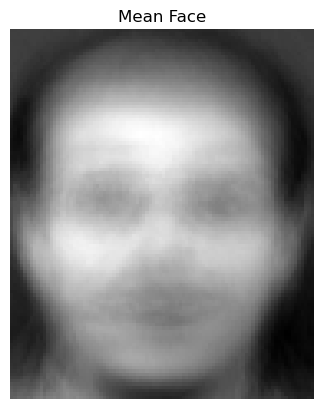

In [7]:
mean_val = np.mean(X, axis=0)
mean_val.shape

# Visualize the mean face
mean_face = mean_val.reshape(shape)
plt.imshow(mean_face, cmap='gray')
plt.title('Mean Face')
plt.axis('off')
plt.show()

In [8]:
X_std = X - mean_val
X_std.shape

(200, 10304)

In [9]:
cov_mat = X_std @ X_std.T
cov_mat.shape

(200, 200)

**Step 6: Compute Eigenvalues, Eigenvectors, and Eigenfaces** - Decompose covariance, convert eigenvectors back to image space, and normalize to form eigenfaces.

In [10]:
# Computing eigenvalues and eigenvectors and sorting them in descending order
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
idx = np.argsort(eigen_vals)[::-1]
eigen_vals = eigen_vals[idx]
eigen_vecs = eigen_vecs[:, idx]
print(eigen_vals.shape)
print(eigen_vecs.shape)

(200,)
(200, 200)


In [11]:
# Converting eigenvectors to the original space
eigen_vecs_converted = X_std.T @ eigen_vecs
eigen_vecs_converted.shape

(10304, 200)

In [12]:
# Normalizing the eigenvectors to get the eigenfaces
eigen_faces = eigen_vecs_converted.T / np.sqrt((eigen_vecs_converted.T **2).sum(axis=1, keepdims=True))
eigen_faces.shape

(200, 10304)

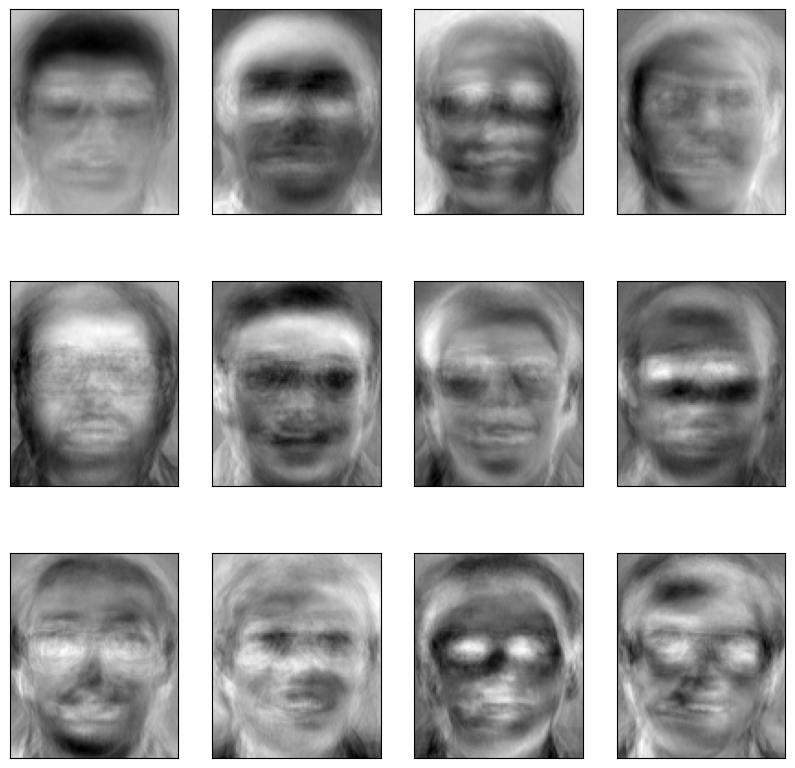

In [13]:
# Visualizing the top 12 eigenfaces
# _ is used to ignore the first return value of plt.subplots which is the figure object
_, axes = plt.subplots(3, 4, figsize=(10, 10), subplot_kw={'xticks':[], 'yticks':[]})
# flattens the 2D array of axes into a 1D array for easy iteration
# Example: if axes is a 2D array of shape (3, 4), axes.flatten() will return a 1D array of shape (12,) containing all the axes in row-major order.
axes = axes.flatten()
for i, (img, ax) in enumerate(zip(eigen_faces, axes)):
    ax.imshow(img.reshape(shape[0], shape[1]), cmap='gray')

plt.show()

**Step 7: Analyze Explained Variance** - Measure and visualize cumulative explained variance to understand component usefulness.

In [14]:
total = sum(eigen_vals)
total

np.float64(3246180294.4550114)

In [15]:
explained_variance = [(i/total) * 100 for i in eigen_vals]
cumulative_explained_variance = np.cumsum(explained_variance)
cumulative_explained_variance

array([ 18.84425736,  31.41199549,  38.58565463,  44.28136274,
        49.47210639,  52.80488477,  55.49841075,  58.11525895,
        60.22270589,  62.02463256,  63.70462931,  65.06305477,
        66.31755833,  67.49103304,  68.5749663 ,  69.57281949,
        70.53916027,  71.42851577,  72.24224615,  73.00305598,
        73.75340247,  74.43442813,  75.07869274,  75.68892259,
        76.29089922,  76.85315225,  77.38999344,  77.91618533,
        78.42383707,  78.90549787,  79.36553455,  79.79843371,
        80.22958225,  80.6412349 ,  81.04474182,  81.44373611,
        81.83307355,  82.19151753,  82.54779034,  82.89193371,
        83.23181555,  83.56647527,  83.87414538,  84.17566866,
        84.47492386,  84.77037034,  85.05388429,  85.33312775,
        85.60208805,  85.86682016,  86.12073029,  86.36954703,
        86.61410984,  86.85194023,  87.08243293,  87.30404799,
        87.52392421,  87.73375788,  87.93951903,  88.14395888,
        88.34459667,  88.54083741,  88.73431093,  88.92

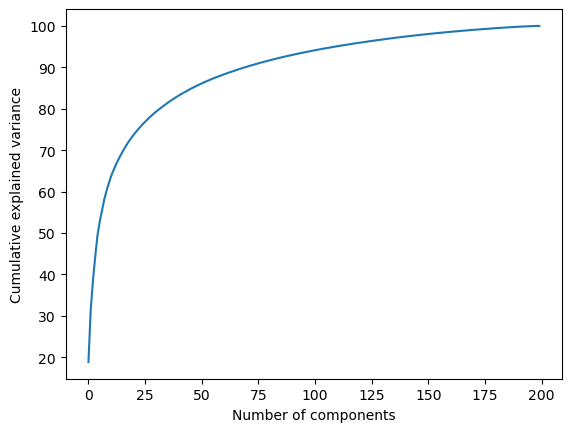

In [16]:
plt.plot(cumulative_explained_variance)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance')
plt.show()

**Step 8: Reconstruct a Training Image at Different Dimensions** - 
Project a sample training image onto eigenfaces and compare reconstruction quality across component counts.

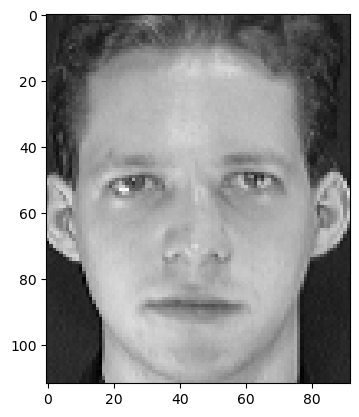

In [17]:
train_img = np.array(Image.open(data_path + 's1/1.pgm'))
plt.imshow(train_img.reshape(shape[0], shape[1]), cmap = 'gray')
plt.show()

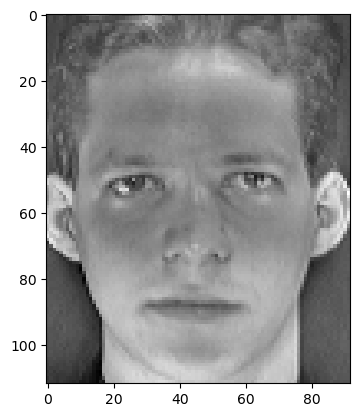

In [18]:
train_img_mean_centered = train_img.flatten() - mean_val
plt.imshow(train_img_mean_centered.reshape(shape[0], shape[1]), cmap = 'gray')
plt.show()

MSEs: 
Error for 0 components: 15032804.362725
Error for 25 components: 4049724.2698144135
Error for 75 components: 1827701.4079742685
Error for 150 components: 203638.73186717436
Error for 175 components: 49207.755846810134
Error for 200 components: 26892.183843105835


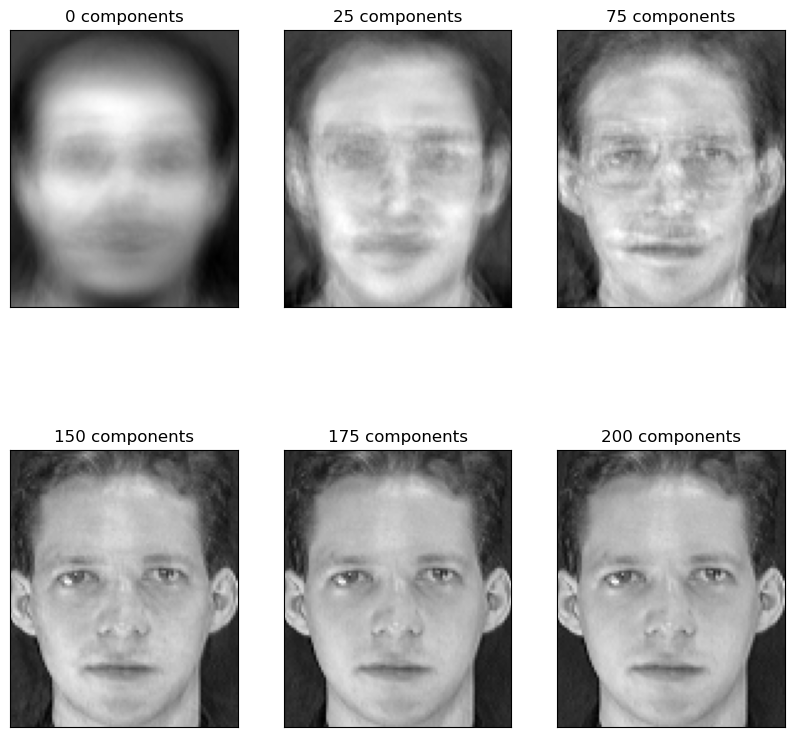

In [19]:
_, axes = plt.subplots(2, 3, figsize=(10, 10), subplot_kw={'xticks':[], 'yticks':[]})
axes = axes.flatten()
interval = [0, 25, 75, 150, 175, 200]

print("MSEs: ")
for i, (img, ax) in enumerate(zip(eigen_faces, axes)):
    E = eigen_faces[:interval[i]].dot(train_img_mean_centered)
    reconstructed_img = eigen_faces[:interval[i]].T.dot(E) + mean_val

    diff = train_img_mean_centered + mean_val - reconstructed_img

    error = np.dot(diff, diff)
    print(f'Error for {interval[i]} components: {error}')

    ax.set_title(f'{interval[i]} components')
    ax.imshow(reconstructed_img.reshape(shape[0], shape[1]), cmap='gray')

plt.show()

**Step 9: Reconstruct a Test Image and Plot MSE Trend** - Repeat reconstruction for an unseen test image and observe error behavior as dimensions increase.

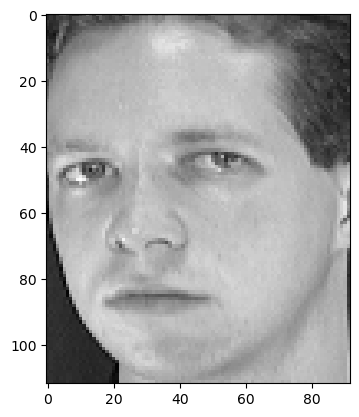

In [20]:
test_img = np.array(Image.open(data_path + 's1/6.pgm'))
plt.imshow(test_img.reshape(shape[0], shape[1]), cmap='gray')
plt.show()

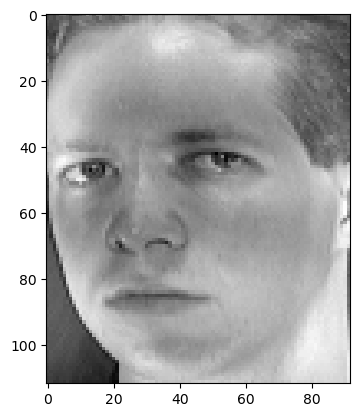

In [21]:
test_img_mean_centered = test_img.flatten() - mean_val
plt.imshow(test_img_mean_centered.reshape(shape[0], shape[1]), cmap='gray')
plt.show()

MSEs: 
Error for 0 components: 23962562.442725
Error for 25 components: 6363349.881231619
Error for 75 components: 4648995.871130322
Error for 150 components: 3653232.256599226
Error for 175 components: 3530343.108785869
Error for 200 components: 3449036.996647555


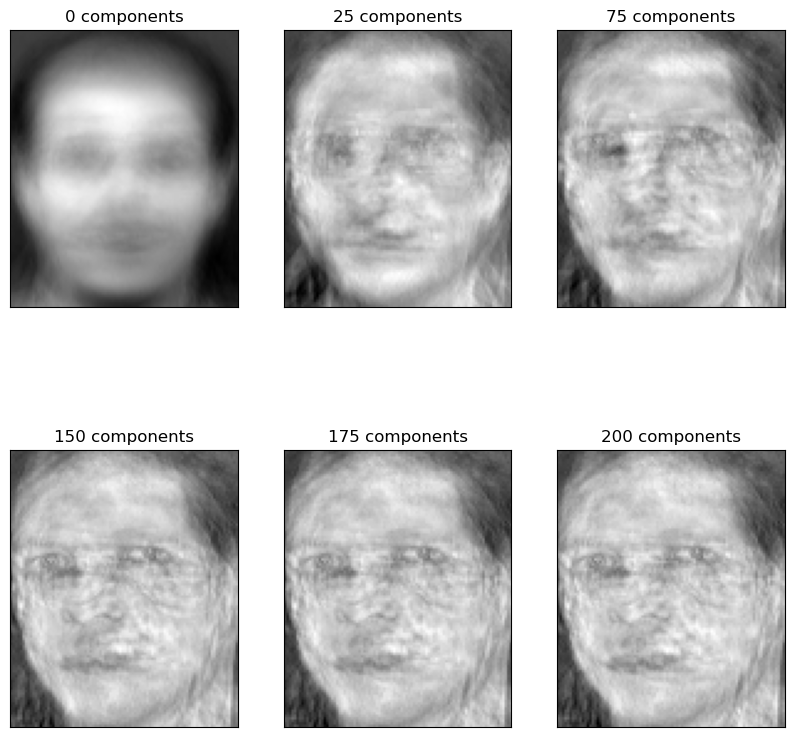

In [22]:
_, axes = plt.subplots(2, 3, figsize=(10, 10), subplot_kw={'xticks':[], 'yticks':[]})
axes = axes.flatten()
interval = [0, 25, 75, 150, 175, 200]

print("MSEs: ")
for i, (img, ax) in enumerate(zip(eigen_faces, axes)):
    E = eigen_faces[:interval[i]].dot(test_img_mean_centered)
    reconstructed_img = eigen_faces[:interval[i]].T.dot(E) + mean_val

    diff = test_img_mean_centered + mean_val - reconstructed_img

    error = np.dot(diff, diff)
    print(f'Error for {interval[i]} components: {error}')

    ax.set_title(f'{interval[i]} components')
    ax.imshow(reconstructed_img.reshape(shape[0], shape[1]), cmap='gray')

plt.show()

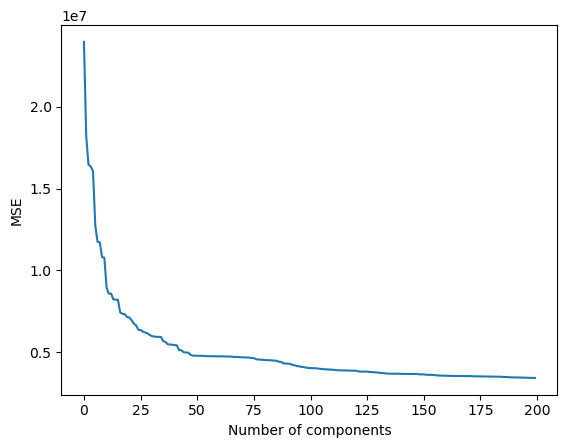

In [23]:
errors = list()

for i in range(200):
    E = eigen_faces[:i].dot(test_img_mean_centered)
    reconstructed_img = eigen_faces[:i].T.dot(E) + mean_val

    diff = test_img_mean_centered + mean_val - reconstructed_img

    error = np.dot(diff, diff)
    errors.append(error)

plt.plot(errors)
plt.xlabel('Number of components')
plt.ylabel('MSE')
plt.show()

**Step 10: Build Eigen-Space Features for All Images** - Project all train/test images into the selected PCA subspace for recognition.

In [42]:
train_E = []
test_E = []

for folder in sorted(os.listdir(data_path)):
    if not folder.startswith('s'):
        continue

    folder_path = os.path.join(data_path, folder)
    image_files = sorted(os.listdir(folder_path), key=lambda name: int(os.path.splitext(name)[0]))

    for idx, filename in enumerate(image_files):
        image = np.array(Image.open(os.path.join(folder_path, filename))).flatten()
        image_mean_centered = image - mean_val
        E = eigen_faces[:200].dot(image_mean_centered)

        if idx < 5:
            train_E.append(E)
        else:
            test_E.append(E)

**Step 11: Define Nearest-Neighbor Prediction in PCA Space** - Create prediction functions that compare projected test and training embeddings.

In [25]:
def predict_single(total, q=25):
    smallest_value = None
    index = None

    E = test_E[total][:q]
    for i, E_compare in enumerate(train_E):
        diff = E - E_compare[:q]
        eps = np.sqrt(np.dot(diff, diff))

        if smallest_value is None or eps < smallest_value:
            smallest_value = eps
            index = y_train[i]

    return index

In [26]:
def predict(q=25):
    total = len(test_E)
    correct = 0

    for i in range(total):
        if predict_single(i, q) == y_test[i]:
            correct += 1

    return correct / total

**Step 12: Evaluate Nearest-Neighbor Accuracy Across Dimensions** - Compute baseline accuracy and analyze recognition performance versus number of PCA dimensions.


In [27]:
partA = predict()
print("Classification Accuracy: ", partA)

Classification Accuracy:  0.87


In [28]:
accs = list()
for q in range(1, 200):
    accs.append(predict(q))

**Step 13: Visualize Nearest-Neighbor Accuracy Curve** - Plot recognition accuracy as PCA dimensionality increases.


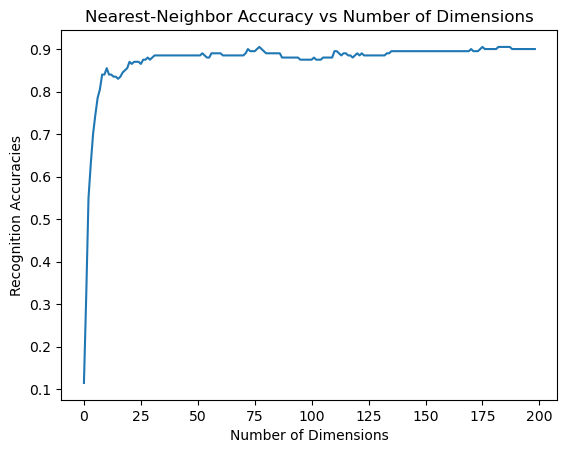

In [29]:
plt.plot(accs)
plt.title("Nearest-Neighbor Accuracy vs Number of Dimensions")
plt.xlabel("Number of Dimensions")
plt.ylabel("Recognition Accuracies")
plt.show()


**Step 14: Train and Compare an SVM Classifier** - Fit an SVM on the same eigenface features and compare its recognition accuracy with the nearest-neighbor baseline.


Nearest-Neighbor Classification Accuracy:  0.87
SVM Classification Accuracy:  0.885


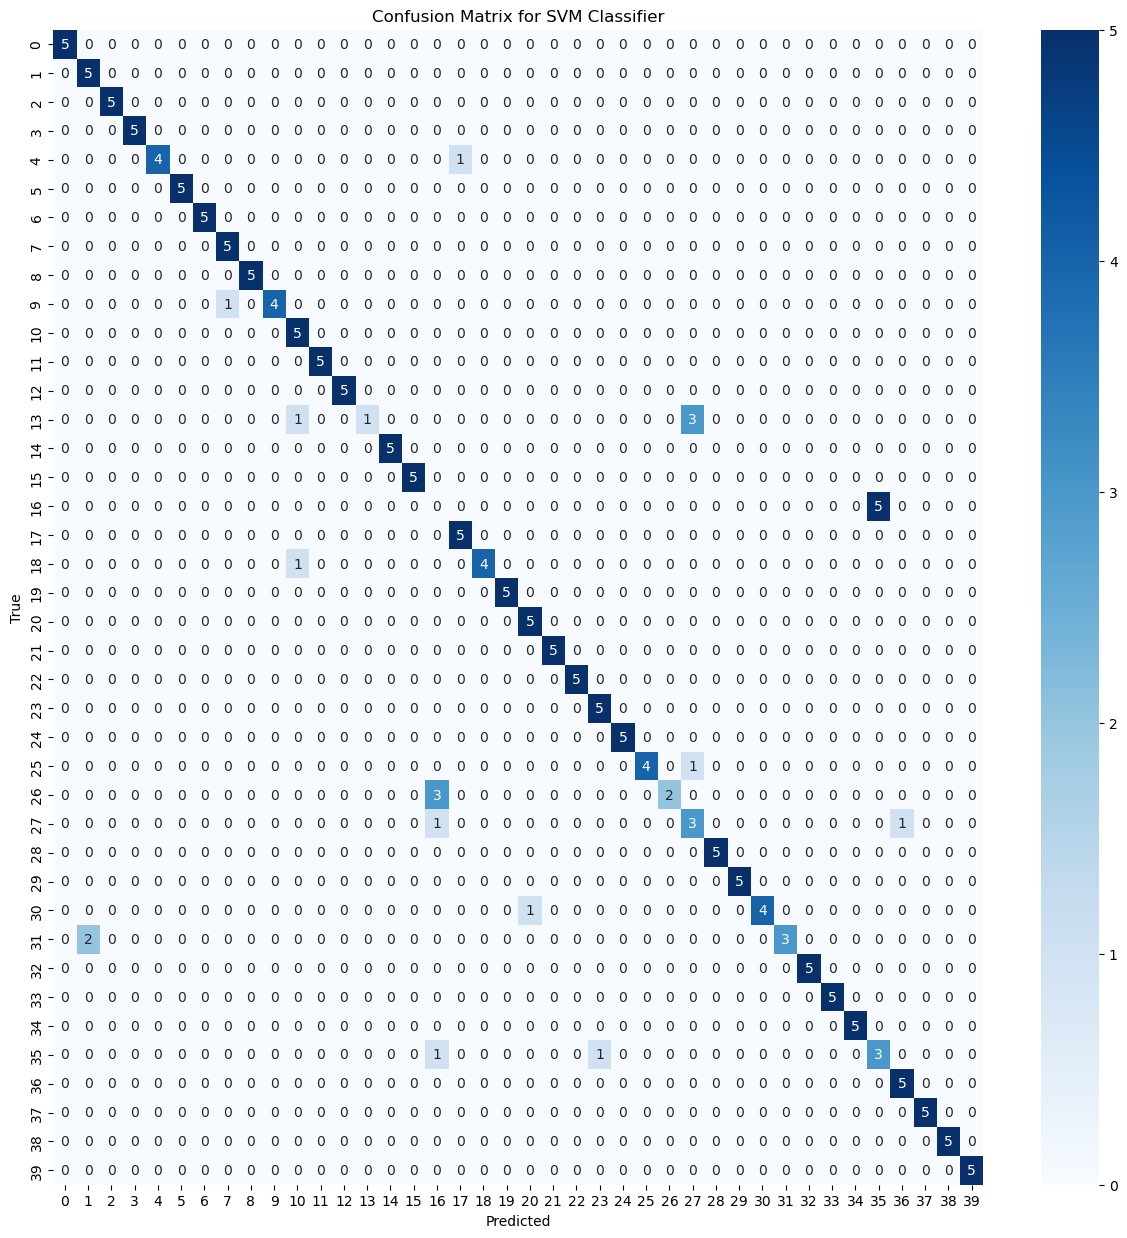

In [40]:
from sklearn.svm import SVC

train_E_np = np.real(np.array(train_E))
test_E_np = np.real(np.array(test_E))
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)


def svm_predict(q=25, kernel='linear', C=1.0):
    clf = SVC(kernel=kernel, C=C, gamma='scale')
    clf.fit(train_E_np[:, :q], y_train_np)
    return clf.predict(test_E_np[:, :q])


def svm_accuracy(q=25, kernel='linear', C=1.0):
    predictions = svm_predict(q=q, kernel=kernel, C=C)
    return np.mean(predictions == y_test_np)


svm_partA = svm_accuracy()
print("Nearest-Neighbor Classification Accuracy: ", partA)
print("SVM Classification Accuracy: ", svm_partA)

# Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
svm_predictions = svm_predict()
cm = confusion_matrix(y_test_np, svm_predictions)
plt.figure(figsize=(15, 15))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for SVM Classifier')
plt.show()


Best Nearest-Neighbor accuracy: 0.9050 at q=78
Best SVM accuracy: 0.9000 at q=43


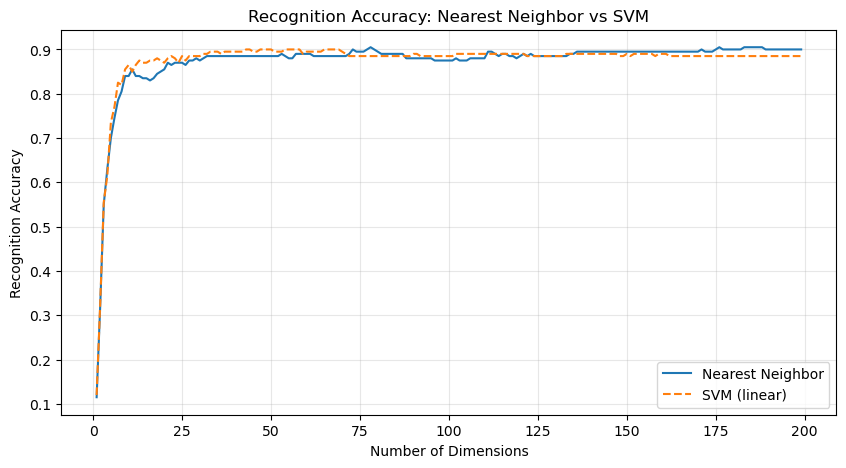

In [31]:
svm_accs = []
for q in range(1, 200):
    svm_accs.append(svm_accuracy(q=q))

best_nn_q = int(np.argmax(accs)) + 1
best_svm_q = int(np.argmax(svm_accs)) + 1

print(f'Best Nearest-Neighbor accuracy: {accs[best_nn_q - 1]:.4f} at q={best_nn_q}')
print(f'Best SVM accuracy: {svm_accs[best_svm_q - 1]:.4f} at q={best_svm_q}')

plt.figure(figsize=(10, 5))
plt.plot(range(1, 200), accs, label='Nearest Neighbor')
plt.plot(range(1, 200), svm_accs, label='SVM (linear)', linestyle='--')
plt.title('Recognition Accuracy: Nearest Neighbor vs SVM')
plt.xlabel('Number of Dimensions')
plt.ylabel('Recognition Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**Step 15: Quantify “Close Enough” vs SVM** - Compare best nearest-neighbor and SVM accuracies in PCA space using absolute and relative gap.

Best NN accuracy  : 0.9050
Best SVM accuracy : 0.9000
Absolute gap      : -0.0050
Relative gap      : -0.56% (of best SVM)
Conclusion for report:
PCA + nearest-neighbor is close enough to SVM (<= 2 percentage-point gap).


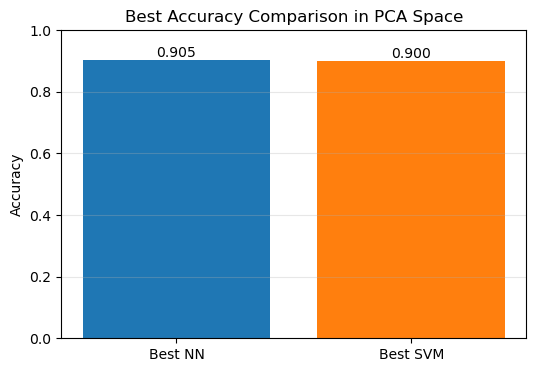

In [32]:
# Best values from the previous sweep
best_nn_acc = float(np.max(accs))
best_svm_acc = float(np.max(svm_accs))

# Gap metrics
abs_gap = best_svm_acc - best_nn_acc
rel_gap_pct = (abs_gap / best_svm_acc) * 100 if best_svm_acc > 0 else 0.0

print(f'Best NN accuracy  : {best_nn_acc:.4f}')
print(f'Best SVM accuracy : {best_svm_acc:.4f}')
print(f'Absolute gap      : {abs_gap:.4f}')
print(f'Relative gap      : {rel_gap_pct:.2f}% (of best SVM)')

# Practical rule-of-thumb for this report
close_enough = abs_gap <= 0.02
print('Conclusion for report:')
if close_enough:
    print('PCA + nearest-neighbor is close enough to SVM (<= 2 percentage-point gap).')
else:
    print('SVM is clearly better (> 2 percentage-point gap).')

plt.figure(figsize=(6, 4))
plt.bar(['Best NN', 'Best SVM'], [best_nn_acc, best_svm_acc], color=['#1f77b4', '#ff7f0e'])
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Best Accuracy Comparison in PCA Space')
for i, val in enumerate([best_nn_acc, best_svm_acc]):
    plt.text(i, val + 0.01, f'{val:.3f}', ha='center')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Step 15: Open-Set Thresholding (Non-Face + Unknown Person)** - Use two thresholds:
    1. Reconstruction error threshold (*tau_face*) to reject non-faces.


In [33]:
# Choose number of PCA components used by the open-set classifier
q_open = 80

# Stack projected training vectors for faster distance computation
train_E_np = np.array(train_E)  # shape: (n_train, 200)

In [34]:
def reconstruction_error(x_flat, q=q_open):
    """Reconstruction SSE in eigenface space."""
    x_centered = x_flat - mean_val
    coeff = eigen_faces[:q].dot(x_centered)
    x_recon = eigen_faces[:q].T.dot(coeff) + mean_val
    diff = x_flat - x_recon
    return float(np.dot(diff, diff))


def nearest_neighbor_distance(x_flat, q=q_open):
    """Minimum Euclidean distance to training embeddings in PCA space."""
    x_centered = x_flat - mean_val
    x_coeff = eigen_faces[:q].dot(x_centered)
    dists = np.linalg.norm(train_E_np[:, :q] - x_coeff, axis=1)
    best_idx = int(np.argmin(dists))
    return float(dists[best_idx]), int(y_train[best_idx])

In [35]:
# 1) Face vs Non-face threshold (calibrated from known training faces)
train_recon_errors = []
for x in X:
    train_recon_errors.append(reconstruction_error(x, q=q_open))

tau_face = float(np.percentile(train_recon_errors, 99))

# 2) Known vs Unknown threshold (calibrated from known test faces)
known_nn_dists = []
for x in X_test:
    d, _ = nearest_neighbor_distance(x, q=q_open)
    known_nn_dists.append(d)

tau_id = float(np.percentile(known_nn_dists, 99))

print(f'q_open = {q_open}')
print(f'tau_face (99th pct reconstruction error) = {tau_face:.4f}')
print(f'tau_id   (99th pct NN distance)         = {tau_id:.4f}')

q_open = 80
tau_face (99th pct reconstruction error) = 1827968.8780
tau_id   (99th pct NN distance)         = 3473.9774


In [36]:
def predict_open_set(x_flat, q=q_open, tau_face=tau_face, tau_id=tau_id):
    """
    Returns one of:
    - ('non-face', None)
    - ('unknown-person', None)
    - ('known-person', predicted_label)
    """
    rerr = reconstruction_error(x_flat, q=q)
    if rerr > tau_face:
        return 'non-face', None, rerr, None

    dmin, pred_label = nearest_neighbor_distance(x_flat, q=q)
    if dmin > tau_id:
        return 'unknown-person', None, rerr, dmin

    return 'known-person', pred_label, rerr, dmin

In [37]:
# Demo on one known test image
known_sample = X_test[0]
status, label, rerr, dmin = predict_open_set(known_sample)
print('Known sample ->', status, label, f'rerr={rerr:.3f}', f'dmin={dmin:.3f}' if dmin is not None else '')

# Demo on synthetic non-face (random noise)
random_non_face = np.random.randint(0, 256, size=shape[0] * shape[1])
status, label, rerr, dmin = predict_open_set(random_non_face)
print('Random sample ->', status, label, f'rerr={rerr:.3f}', f'dmin={dmin:.3f}' if dmin is not None else '')

Known sample -> non-face None rerr=4524475.002 
Random sample -> non-face None rerr=57158018.386 


**Conclusion** - This workflow preprocesses face images, extracts eigenfaces using PCA, reconstructs images at different dimensions, and now compares nearest-neighbor recognition with an SVM classifier in the same eigenface space before demonstrating open-set rejection.
